In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler

In [9]:
df = pd.read_csv("data/raw/Media-Matrix-Yarrowia-Narrow-Fixed.csv")
print(df.shape)

(27, 13)


In [10]:
# removing glucose glycerol urea and ammonium sulfate will simply visuals

df= df.drop([0, 1, 2, 3, 5, 9,12, 17])

In [16]:
#drop pubchem id and experiment 1 because it was dubious
df = df.drop(df.columns[2:4], axis=1)

In [17]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number])

# Replace 0s and apply log10
pseudocount = 1e-10
df_log = np.log10(numeric_cols.replace(0, pseudocount))

In [18]:
# Add back Compound column before melting
df_log['Compound'] = df['Compound']
df_log['Annotate'] = df['Annotate']

In [ ]:
#changes made here as I remove 1_YAR

df_long = pd.melt(
    df_log,
    id_vars=['Compound', 'Annotate'],       # keep these columns as identifiers
    value_vars=[                            # columns to unpivot
        '2a_YAR', '2b_YAR', '2c_YAR', '2d_YAR',
        '3a_YAR', '3b_YAR', '3c_YAR', '4_YAR', '5_YAR'
    ],
    var_name='Sample',                      # name of the new variable column
    value_name='Log10_Concentration'
)

In [21]:
filtered_df_long = df_long.replace(-10, np.nan)

In [22]:
# Get the original Compound order
compound_order = df['Compound'].tolist()

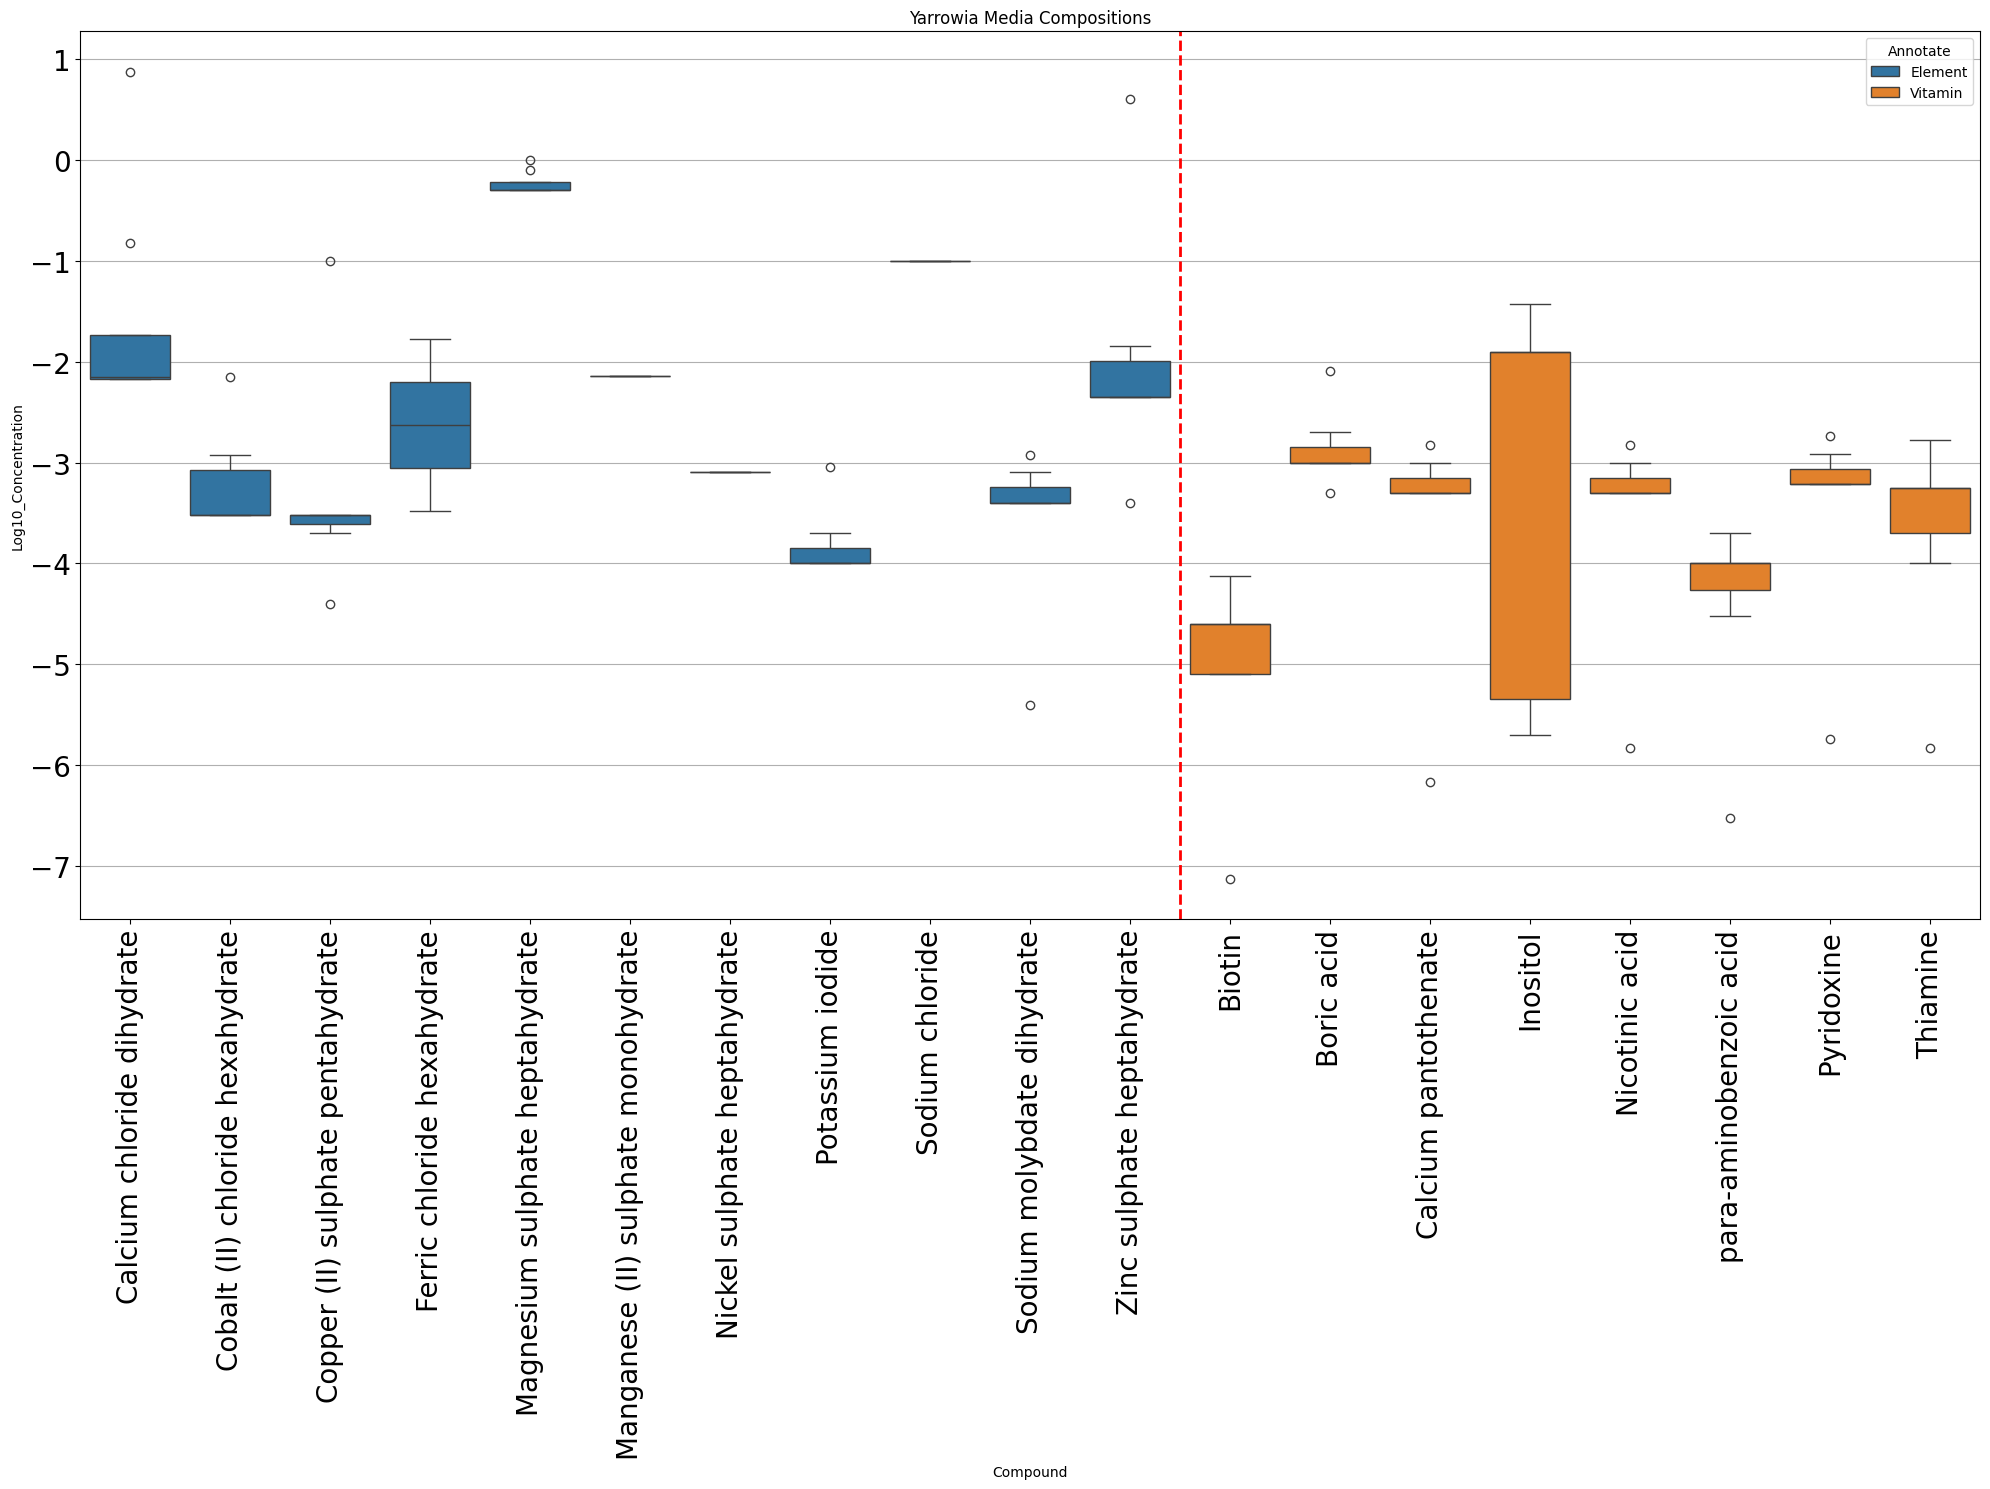

In [24]:
plt.figure(figsize=(20, 15))
sns.boxplot(data=df_long[df_long['Log10_Concentration'] > -10],  # exclude pseudocount
            x='Compound', y='Log10_Concentration', hue='Annotate', order=compound_order)
plt.xticks(size = 20, rotation=90)
plt.yticks(size = 20)
plt.title('Yarrowia Media Compositions')
plt.grid(axis='y')
plt.axvline(x=10.5, color='r', linestyle='--', linewidth=2)
plt.tight_layout()
plt.show()